# Week 4 · Notebook 3 — GA Theory: Schemata, Deception, Runtime Analysis and Exact Markov Models

**Goals**
- Derive Holland's **schema theorem** with explicit disruption bounds for one-point crossover and bit-flip mutation,
  and check the inequality empirically (Monte Carlo estimate of $E[m(H,t+1)]$ vs the bound) during a real run.
- State the **building-block hypothesis** and its critique; construct **deceptive trap functions** (verified
  exhaustively) on which a GA fails unless the linkage is tight.
- Verify two exact **runtime results** for the (1+1) EA: $e\,n\ln n$ leading term on OneMax (Droste, Jansen &
  Wegener 2002) via an exact Markov chain *and* simulation, and $\frac{e-1}{2}n^2$ on LeadingOnes
  (Böttcher, Doerr & Neumann 2010).
- Build the exact **Nix–Vose Markov chain** of a tiny GA (all 330 populations) and compare it with simulation.

**Prerequisites:** Notebooks 1–2, Markov chains (transition matrices, absorption, stationary distributions).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import itertools
from math import factorial
from scipy import stats
from utils import PALETTE

## 1. The schema theorem

A **schema** $H \in \lbrace 0, 1, \ast\rbrace^L$ is the set of strings matching it on the fixed (non-$\ast$)
positions. Its **order** $o(H)$ is the number of fixed positions; its **defining length** $\delta(H)$ is the distance
between the first and last fixed position. Let $m(H,t)$ be the number of instances in the population at generation
$t$, $f(H,t)$ their mean fitness and $\bar f(t)$ the population mean.

**Theorem (Holland 1975; form of Goldberg 1989).** For the canonical GA — roulette selection, one-point crossover
with probability $p_c$, bit-flip mutation with rate $p_m$, generational replacement —

$$E\left[m(H,t+1) \mid P_t\right] \;\ge\; m(H,t)\,\frac{f(H,t)}{\bar f(t)}\left[1 - p_c\frac{\delta(H)}{L-1}\right]\,(1-p_m)^{o(H)} \;\ge\; m(H,t)\,\frac{f(H,t)}{\bar f(t)}\left[1 - p_c\frac{\delta(H)}{L-1} - o(H)\,p_m\right].$$

*Proof.* Each child is produced from two parents $a, b$ drawn i.i.d. by roulette, so
$q := P(a \in H) = P(b \in H) = m(H,t) f(H,t) / (N \bar f(t))$. Consider a child that takes its head from $a$ and its
tail from $b$. (i) Without crossover (probability $1-p_c$) it equals $a$: in $H$ with probability $q$.
(ii) With crossover, if the cut does not fall strictly inside the defining region — probability
$1 - \delta/(L-1)$ — all fixed positions come from the *same* parent ($a$ or $b$, depending on the side), which is in
$H$ with probability $q$ either way. Ignoring the (non-negative) chance that a disruptive cut still produces an
instance gives $P(\text{child} \in H \text{ before mutation}) \ge q\,[1 - p_c\delta/(L-1)]$. Mutation leaves all
$o(H)$ fixed bits intact with probability $(1-p_m)^{o(H)} \ge 1 - o(H)p_m$ (Bernoulli). Summing over the $N$
children (linearity of expectation, whatever the dependence within a pair) gives the claim. $\square$

What the theorem does **not** say: it is an inequality for *one* generation, in *expectation*, and $f(H,t)$ changes
with the population. It cannot be iterated to give "exponentially increasing trials" without further assumptions —
the central point of the critiques below. We now check the inequality numerically, estimating
$E[m(H,t+1)\mid P_t]$ by re-running the step from the *same* $P_t$ many times.

In [2]:
def roulette_idx(f, size, rng):
    c = np.cumsum(f, dtype=float)
    return np.searchsorted(c, rng.random(size) * c[-1], side="right")


def canonical_step(P, f_fun, rng, pc, pm, reps=1):
    """One generation of the canonical GA from population P, replicated `reps` times -> (reps, N, L)."""
    N, L = P.shape
    f = f_fun(P)
    par = P[roulette_idx(f, (reps, N), rng)]                    # (reps, N, L)
    a, b = par[:, 0::2], par[:, 1::2]
    cut = rng.integers(1, L, (reps, N // 2, 1))
    do = rng.random((reps, N // 2, 1)) < pc
    tail = (np.arange(L) >= cut) & do
    C = np.concatenate([np.where(tail, b, a), np.where(tail, a, b)], axis=1)
    return C ^ (rng.random(C.shape) < pm)


def in_schema(X, pos, val):
    return np.all(X[..., pos] == val, axis=-1)


L_s, N_s, pc, pm = 16, 40, 0.8, 0.02
w = np.linspace(1, 2, L_s)
f_sch = lambda X: 1.0 + (X * w).sum(-1)                     # positive, weighted OneMax-like fitness
schemata = []
for o in (1, 2, 3, 4):
    for _ in range(8):
        pos = np.sort(rng.choice(L_s, o, replace=False))
        schemata.append((pos, np.ones(o, dtype=bool)))
        schemata.append((pos, rng.random(o) < 0.5))
P = rng.random((N_s, L_s)) < 0.5
records = []
for t in range(12):
    f = f_sch(P); fbar = f.mean()
    nxt = canonical_step(P, f_sch, rng, pc, pm, reps=3000)
    for pos, val in schemata:
        inst = in_schema(P, pos, val)
        m = inst.sum()
        if m == 0:
            continue
        delta, o = pos[-1] - pos[0], len(pos)
        ratio = f[inst].mean() / fbar
        bound_tight = m * ratio * (1 - pc * delta / (L_s - 1)) * (1 - pm) ** o
        bound_holland = m * ratio * (1 - pc * delta / (L_s - 1) - o * pm)
        counts = in_schema(nxt, pos, val).sum(1)
        records.append((t, o, delta, m, counts.mean(), counts.std() / np.sqrt(len(counts)), bound_tight, bound_holland))
    P = canonical_step(P, f_sch, rng, pc, pm, reps=1)[0]
R = np.array(records)
Ehat, se, b_t, b_h = R[:, 4], R[:, 5], R[:, 6], R[:, 7]
print(f"{len(R)} (schema, generation) pairs checked")
check_true(np.all(Ehat + 4 * se >= b_t), "E[m(H,t+1)] >= tight bound (with (1-pm)^o) for every pair (4 SE margin)")
check_true(np.all(b_t >= b_h - 1e-12), "tight bound >= Holland's linearised bound (Bernoulli's inequality)")
print(f"median slack E[m]/bound: {np.median(Ehat / np.maximum(b_t, 1e-9)):.3f};  "
      f"fraction of pairs with slack > 1.2: {np.mean(Ehat > 1.2 * b_t):.2f}")

701 (schema, generation) pairs checked
[PASS] E[m(H,t+1)] >= tight bound (with (1-pm)^o) for every pair (4 SE margin)
[PASS] tight bound >= Holland's linearised bound (Bernoulli's inequality)
median slack E[m]/bound: 1.494;  fraction of pairs with slack > 1.2: 0.62


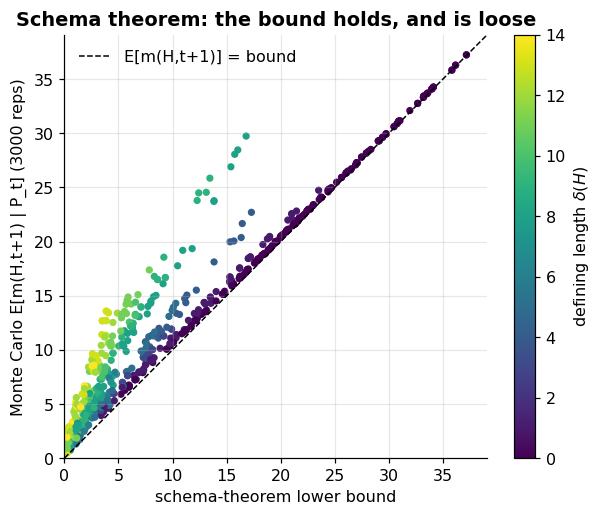

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 5))
sc = ax.scatter(b_t, Ehat, c=R[:, 2], s=14, cmap="viridis")
lim = [0, max(Ehat.max(), b_t.max()) * 1.05]
ax.plot(lim, lim, "k--", lw=1, label="E[m(H,t+1)] = bound")
ax.set(xlim=lim, ylim=lim, xlabel="schema-theorem lower bound", ylabel="Monte Carlo E[m(H,t+1) | P_t] (3000 reps)",
       title="Schema theorem: the bound holds, and is loose")
plt.colorbar(sc, label=r"defining length $\delta(H)$")
ax.legend(loc="upper left")
savefig("w4_schema_theorem.png"); plt.show()

Every point lies above the diagonal: the inequality holds. It is loose mostly for long schemata (large
$\delta$), because the proof counts every cut inside the defining region as destructive, whereas in a
converging population the other parent is often an instance too, and crossover can also *create* instances.

## 2. The building-block hypothesis and its critique

**Building-block hypothesis** (Holland 1975; Goldberg 1989): a GA works by implicitly identifying short, low-order,
above-average schemata ("building blocks") and recombining them into ever better strings. Main critiques:

* The schema theorem is a statement about *one* generation of *expected* counts with *observed* (not static)
  schema fitness; "implicit parallelism" arguments based on it do not yield performance guarantees
  (Grefenstette & Baker 1989; Grefenstette 1993; Vose 1999 — exact models do not need schemata at all).
* On the Royal Road functions designed to reward building blocks (Mitchell, Forrest & Holland 1992) a random
  mutation hill climber outperformed the GA; the GA suffered from *hitchhiking* of bad alleles on good blocks
  (Forrest & Mitchell 1993; Mitchell, Holland & Forrest 1994).
* Price's theorem (Price 1970) gives an *exact* covariance form of selection plus transmission, of which the schema
  theorem is a special case (Altenberg 1995).

What survives is a sharper statement: recombination helps when the representation places interacting variables
close together (linkage) and the population is large enough to sample each block's alternatives (Goldberg, Deb &
Clark 1992; Harik et al. 1999). Deceptive traps make this precise.

## 3. Deceptive trap functions

**Trap of order $k$** (Ackley 1987; Deb & Goldberg 1993) on a block $u$ with $|u| = $ number of ones:

$$\mathrm{trap}_k(u) = \begin{cases} k, & |u| = k,\\ k - 1 - |u|, & \text{otherwise.}\end{cases}$$

The global optimum is $1^k$, but every lower-order statistic points to $0^k$. We verify **full deception**
exhaustively for $k = 4$: for every set of fixed positions of size $1 \le o \lt k$, the all-zeros schema has the
highest average fitness among its $2^{o}$ competitors.

In [4]:
def trap(u_ones, k):
    return np.where(u_ones == k, k, k - 1 - u_ones)

k_tr = 4
allb = np.array(list(itertools.product([0, 1], repeat=k_tr)), dtype=bool)
ft = trap(allb.sum(1), k_tr)
deceptive = True
for o in range(1, k_tr):
    for pos in itertools.combinations(range(k_tr), o):
        avgs = {}
        for val in itertools.product([0, 1], repeat=o):
            sel = np.all(allb[:, list(pos)] == np.array(val, bool), axis=1)
            avgs[val] = ft[sel].mean()
        deceptive &= max(avgs, key=avgs.get) == (0,) * o
check_true(deceptive, "trap-4 is fully deceptive: 0-schemata win every competition of order 1..3")
print("order-1 averages: f(0***) =", ft[~allb[:, 0]].mean(), " f(1***) =", ft[allb[:, 0]].mean())

[PASS] trap-4 is fully deceptive: 0-schemata win every competition of order 1..3
order-1 averages: f(0***) = 1.5  f(1***) = 1.125


**Experiment.** $m = 10$ concatenated trap-4 blocks ($L = 40$, optimum $40$). The GA (population 200, binary
tournament, crossover probability 1, bit-flip $1/L$, 1-elitism, 60,000 evaluations, 10 seeds) is run with:

* one-point crossover, **tight linkage**: block $j$ occupies positions $4j..4j+3$;
* one-point crossover, **loose linkage**: block $j$ occupies positions $j, j+10, j+20, j+30$;
* **uniform** crossover (linkage irrelevant: it disrupts every block);
* the **(1+1) EA** (no population, no crossover) with the same budget.

The metric is the number of blocks set to $1111$ in the best string found.

In [5]:
kb, mb = 4, 10
Lt = kb * mb
tight = np.arange(Lt)
loose = np.arange(Lt).reshape(kb, mb).T.ravel()

def trap_blocks(X, layout):
    return X[..., layout].reshape(*X.shape[:-1], mb, kb).sum(-1)

def trap_fitness(X, layout):
    return trap(trap_blocks(X, layout), kb).sum(-1)

def ga_trap(layout, xo, rng, N=200, budget=60_000):
    P = rng.random((N, Lt)) < 0.5
    f = trap_fitness(P, layout); ev = N
    best = P[np.argmax(f)].copy(); fbest = f.max()
    while ev + N <= budget:
        T = rng.integers(0, N, (N, 2))
        par = P[T[np.arange(N), np.argmax(f[T], 1)]]
        a, b = par[0::2], par[1::2]
        msk = (np.arange(Lt) >= rng.integers(1, Lt, (N // 2, 1))) if xo == "one-point" else rng.random((N // 2, Lt)) < 0.5
        C = np.concatenate([np.where(msk, b, a), np.where(msk, a, b)])
        C ^= rng.random(C.shape) < 1 / Lt
        fc = trap_fitness(C, layout); ev += N
        if fbest > fc.max():
            wi = np.argmin(fc); C[wi] = best; fc[wi] = fbest
        P, f = C, fc
        if f.max() > fbest:
            best, fbest = P[np.argmax(f)].copy(), f.max()
    return int((trap_blocks(best, layout) == kb).sum())

def one_plus_one_trap(reps, rng, budget=60_000):
    """(1+1) EA with rate 1/L on concatenated traps, `reps` independent runs vectorised; blocks solved per run."""
    x = rng.random((reps, Lt)) < 0.5
    fx = trap_fitness(x, tight)
    for _ in range(budget - 1):
        y = x ^ (rng.random((reps, Lt)) < 1 / Lt)
        fy = trap_fitness(y, tight)
        acc = fy >= fx
        x[acc], fx[acc] = y[acc], fy[acc]
    return [int(c) for c in (trap_blocks(x, tight) == kb).sum(-1)]

trap_res = {
    "1-pt, tight linkage": [ga_trap(tight, "one-point", np.random.default_rng(s)) for s in range(10)],
    "1-pt, loose linkage": [ga_trap(loose, "one-point", np.random.default_rng(s)) for s in range(10)],
    "uniform crossover": [ga_trap(tight, "uniform", np.random.default_rng(s)) for s in range(10)],
    "(1+1) EA": one_plus_one_trap(10, np.random.default_rng(0), budget=60_000),
}
for name, v in trap_res.items():
    print(f"{name:22s} blocks solved (of 10): {v}")
check_true(min(trap_res["1-pt, tight linkage"]) > max(trap_res["1-pt, loose linkage"] + trap_res["uniform crossover"]),
           "tight linkage + one-point crossover beats loose linkage and uniform crossover on every seed")

1-pt, tight linkage    blocks solved (of 10): [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
1-pt, loose linkage    blocks solved (of 10): [2, 1, 4, 0, 3, 3, 1, 2, 1, 1]
uniform crossover      blocks solved (of 10): [2, 1, 1, 1, 1, 2, 1, 2, 0, 1]
(1+1) EA               blocks solved (of 10): [0, 2, 0, 1, 0, 0, 1, 1, 0, 1]
[PASS] tight linkage + one-point crossover beats loose linkage and uniform crossover on every seed


The (1+1) EA (10 independent runs, same budget) solves only the few blocks that happen to climb to $1111$ from 3
ones before sliding towards $0000$. From a block at $0000$ the only accepted jump to $1111$ flips four specific
bits (and, essentially, nothing else), which takes $1/\big(L^{-4}(1-1/L)^{L-4}\big) \approx 6\times 10^6$
evaluations in expectation for $L = 40$; even with all ten blocks at $0000$ the *first* such jump needs
$\approx 6\times 10^5$ evaluations, ten times the budget.

With tight linkage one-point crossover rarely cuts inside a 4-bit block ($\delta = 3$, disruption probability
$3/39$) and the GA assembles the blocks; with the same bits spread over the string ($\delta = 30$, disruption
$30/39$) or with uniform crossover, blocks are destroyed as fast as selection finds them and the population is
pulled to the deceptive attractor. This is the positive content of the building-block hypothesis — and why
linkage-learning GAs and estimation-of-distribution algorithms (Harik et al. 1999 ECGA; Pelikan, Goldberg &
Cantú-Paz 1999 BOA) learn the block structure instead of assuming it.

## 4. Runtime analysis of the (1+1) EA

The (1+1) EA: start from uniform $x$; repeat: flip each bit independently with probability $1/n$; accept the
offspring if it is not worse. $T$ = number of offspring evaluations until the optimum is first sampled.

### 4.1 OneMax

**Theorem (Droste, Jansen & Wegener 2002).** On $\mathrm{OneMax}(x) = \sum_i x_i$, $E[T] = \Theta(n\log n)$,
with $E[T] \le e\,n(\ln n + 1)$. (Fitness-level argument: from $i$ ones, an improvement occurs with probability
$\ge (n-i)\frac1n(1-\frac1n)^{n-1} \ge \frac{n-i}{en}$, and $\sum_{i}\frac{en}{n-i} = e\,n H_n$.) Later work pinned
the leading term down to $e\,n\ln n$ (Sudholt 2013 proved a lower bound $e\,n\ln n - O(n\log\log n)$), and
Hwang, Panholzer, Rolin, Tsai & Chen (2018) computed the lower-order terms.

Because OneMax depends only on the number of ones $i$, the (1+1) EA induces a Markov chain on $i$. From $i$, the
offspring has $i - A + B$ ones with independent $A \sim \mathrm{Bin}(i, 1/n)$, $B \sim \mathrm{Bin}(n-i, 1/n)$;
moves to $j \gt i$ happen with probability $p_{ij}$, anything else leaves $i$ unchanged. Hence

$$E[T_i] = \frac{1 + \sum_{j \gt i} p_{ij}\,E[T_j]}{\sum_{j \gt i} p_{ij}}, \qquad E[T] = \sum_i \binom{n}{i}2^{-n}E[T_i].$$

We solve this recursion **exactly** (up to truncating $A, B \le 20$, whose neglected mass is $\lt 10^{-18}$),
check it against a simulation of the actual bit-string algorithm, and fit the leading constant.

In [6]:
def onemax_exact(n, K=20):
    """Exact E[T] of the (1+1) EA with p = 1/n on OneMax from a uniform start (backward recursion over i)."""
    p = 1.0 / n
    E = np.zeros(n + 1)
    kk = np.arange(K + 1)
    for i in range(n - 1, -1, -1):
        pa = stats.binom.pmf(kk, i, p)                    # ones -> zeros
        pb = stats.binom.pmf(kk, n - i, p)                # zeros -> ones
        diff = np.convolve(pb, pa[::-1])                  # distribution of B - A, offset K
        gains = np.arange(-K, K + 1)
        up = (gains > 0) & (i + gains <= n)
        pij, js = diff[up], i + gains[up]
        E[i] = (1 + pij @ E[js]) / pij.sum()
    w0 = stats.binom.pmf(np.arange(n + 1), n, 0.5)
    return float(w0 @ E)


def one_plus_one_sim(n, fitness, reps, rng, max_steps=10**7):
    """Vectorised (1+1) EA on bit strings: returns the number of evaluations T for each of `reps` runs."""
    X = rng.random((reps, n)) < 0.5
    fx = fitness(X)
    T = np.zeros(reps, dtype=np.int64)
    done = fx == n
    t = 0
    while not done.all() and t < max_steps:
        t += 1
        Y = X ^ (rng.random((reps, n)) < 1.0 / n)
        fy = fitness(Y)
        acc = (fy >= fx) & ~done
        X[acc], fx[acc] = Y[acc], fy[acc]
        newly = acc & (fx == n)
        T[newly] = t
        done |= newly
    return T

onemax = lambda X: X.sum(-1)
sim_rows = []
for n_ in (25, 50, 100, 200):
    Ts = one_plus_one_sim(n_, onemax, 200 if n_ < 200 else 120, np.random.default_rng(n_))
    ex = onemax_exact(n_)
    sim_rows.append((n_, Ts.mean(), Ts.std() / np.sqrt(len(Ts)), ex))
    print(f"n={n_:4d}: simulated E[T] = {Ts.mean():8.1f} ± {Ts.std() / np.sqrt(len(Ts)):6.1f}   exact chain = {ex:8.1f}"
          f"   e n ln n = {np.e * n_ * np.log(n_):8.1f}")
check_true(all(abs(m - ex) < 3.5 * s_ for _, m, s_, ex in sim_rows), "bit-string simulation agrees with the exact chain (3.5 SE)")

n=  25: simulated E[T] =    180.9 ±    5.4   exact chain =    176.7   e n ln n =    218.7


n=  50: simulated E[T] =    457.7 ±   10.8   exact chain =    443.2   e n ln n =    531.7


n= 100: simulated E[T] =   1067.8 ±   23.6   exact chain =   1069.5   e n ln n =   1251.8


n= 200: simulated E[T] =   2557.1 ±   60.0   exact chain =   2509.8   e n ln n =   2880.5
[PASS] bit-string simulation agrees with the exact chain (3.5 SE)


In [7]:
ns_big = np.array([100, 200, 400, 700, 1000, 1500, 2000, 3000])
Ex = np.array([onemax_exact(int(n_)) for n_ in ns_big])
Xfit = np.c_[ns_big * np.log(ns_big), ns_big, np.log(ns_big), np.ones(len(ns_big))]
coef, *_ = np.linalg.lstsq(Xfit, Ex, rcond=None)
print(f"fit E[T] = a n ln n + b n + c ln n + d:  a = {coef[0]:.4f}, b = {coef[1]:.4f}, c = {coef[2]:.3f}, d = {coef[3]:.2f}")
check_close(coef[0], np.e, "leading constant a of the exact E[T] (theory: e)", atol=0.01)
check_true(np.all(Ex <= np.e * ns_big * (np.log(ns_big) + 1)), "exact E[T] <= e n (ln n + 1) (Droste-Jansen-Wegener upper bound)")

fit E[T] = a n ln n + b n + c ln n + d:  a = 2.7182, b = -1.8920, c = 1.269, d = 1.11
[PASS] leading constant a of the exact E[T] (theory: e): got 2.718229, expected 2.718282
[PASS] exact E[T] <= e n (ln n + 1) (Droste-Jansen-Wegener upper bound)


The fitted leading constant matches $e$. The fitted linear coefficient $b \approx -1.89$ is consistent with the
full expansion of Hwang, Panholzer, Rolin, Tsai & Chen (2018),

$$E[T] = e\,n\ln n + c_1 n + \tfrac{e}{2}\ln n + c_2 + O\!\left(\tfrac{\log n}{n}\right), \qquad c_1 = -1.89254\ldots,$$

which rigorously confirmed the value $c_1 \approx -1.9$ anticipated by Garnier, Kallel & Schoenauer (1999). The
four-parameter fit is ill-conditioned in its lower-order terms ($c$ fitted $\approx 1.27$ vs $e/2 \approx 1.36$), so
we test the expansion directly: if it is right, the residual
$E[T] - (e\,n\ln n + c_1 n + \tfrac e2 \ln n)$ of the *exact* chain must converge to a constant $c_2$ at rate
$O(\log n / n)$. Since $c_1 \lt 0$, $e\,n\ln n$ *overestimates* $E[T]$ at practical sizes (by about $1.89\,n$).

In [8]:
c1_hwang = -1.8925417883
resid = Ex - (np.e * ns_big * np.log(ns_big) + c1_hwang * ns_big + np.e / 2 * np.log(ns_big))
print("residual E[T] - (e n ln n + c1 n + (e/2) ln n):", " ".join(f"{r_:.3f}" for r_ in resid))
check_true(np.all(np.diff(resid) < 0) and resid[-1] - resid[-2] > -0.01 and np.all(np.abs(resid) < 1),
           "exact chain matches the Hwang et al. expansion: residual is O(1), monotone and converging (c2 ~ 0.6)")

residual E[T] - (e n ln n + c1 n + (e/2) ln n): 0.719 0.668 0.638 0.623 0.617 0.611 0.608 0.605
[PASS] exact chain matches the Hwang et al. expansion: residual is O(1), monotone and converging (c2 ~ 0.6)


### 4.2 LeadingOnes

$\mathrm{LO}(x)$ = number of leading ones. **Theorem (Böttcher, Doerr & Neumann 2010).** For the (1+1) EA with
mutation rate $p$ from a uniform start,

$$E[T] = \frac{1}{2p^2}\left((1-p)^{-n+1} - (1-p)\right), \quad\text{so for } p = \tfrac1n:\ E[T] = \frac{e-1}{2}\,n^2\,(1 + o(1)) \approx 0.859\,n^2.$$

*Proof sketch.* With LO $= i$, an improvement needs bit $i+1$ flipped and bits $1..i$ untouched: probability
$p(1-p)^i$. The bits after the first zero are uniformly random at all times (they never influenced a decision),
so each level $i$ is *visited* with probability $1/2$. Summing $\frac12\cdot\frac{1}{p(1-p)^i}$ over $i = 0..n-1$
gives the formula. The same analysis shows the optimal static rate is $p \approx 1.59/n$, giving
$\approx 0.772\,n^2$.

We check the formula by simulating the actual bit-string algorithm (which knows nothing of the proof).

In [9]:
def leading_ones(X):
    return np.argmin(np.c_[X, np.zeros((*X.shape[:-1], 1), bool)], axis=-1)

def lo_formula(n, p=None):
    p = 1.0 / n if p is None else p
    return ((1 - p) ** (-n + 1) - (1 - p)) / (2 * p * p)

lo_rows = []
for n_ in (20, 40, 60, 80):
    Ts = one_plus_one_sim(n_, leading_ones, 200, np.random.default_rng(1000 + n_))
    lo_rows.append((n_, Ts.mean(), Ts.std() / np.sqrt(len(Ts)), lo_formula(n_)))
    print(f"n={n_:3d}: simulated E[T] = {Ts.mean():8.1f} ± {Ts.std() / np.sqrt(len(Ts)):5.1f}   "
          f"formula = {lo_formula(n_):8.1f}   0.859 n^2 = {(np.e - 1) / 2 * n_**2:8.1f}")
check_true(all(abs(m - th) < 3.5 * s_ for _, m, s_, th in lo_rows), "LeadingOnes: simulation agrees with the exact formula (3.5 SE)")
check_close(lo_formula(10**6) / 1e12, (np.e - 1) / 2, "E[T]/n^2 -> (e-1)/2 for p = 1/n", atol=1e-5)
ps = np.linspace(0.5, 3, 2501)
ratio = [lo_formula(10**5, c / 10**5) / 1e10 for c in ps]
c_opt = ps[int(np.argmin(ratio))]
print(f"optimal static rate: p = {c_opt:.3f}/n giving E[T] = {min(ratio):.4f} n^2")
check_close(c_opt, 1.59, "optimal mutation rate constant for LeadingOnes", atol=0.01)

n= 20: simulated E[T] =    348.2 ±  10.0   formula =    340.0   0.859 n^2 =    343.7


n= 40: simulated E[T] =   1397.0 ±  26.8   formula =   1367.4   0.859 n^2 =   1374.6


n= 60: simulated E[T] =   3093.6 ±  48.3   formula =   3082.1   0.859 n^2 =   3092.9


n= 80: simulated E[T] =   5406.8 ±  75.8   formula =   5484.1   0.859 n^2 =   5498.5
[PASS] LeadingOnes: simulation agrees with the exact formula (3.5 SE)
[PASS] E[T]/n^2 -> (e-1)/2 for p = 1/n: got 0.859141, expected 0.859141
optimal static rate: p = 1.594/n giving E[T] = 0.7721 n^2
[PASS] optimal mutation rate constant for LeadingOnes: got 1.594, expected 1.59


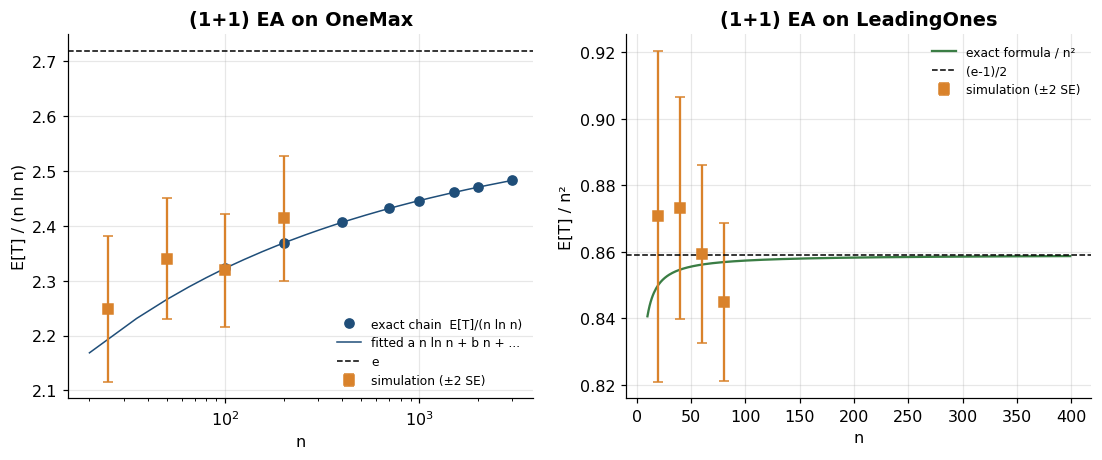

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
nn = np.linspace(20, 3000, 200)
ax[0].plot(ns_big, Ex / (ns_big * np.log(ns_big)), "o", color=PALETTE["blue"], label="exact chain  E[T]/(n ln n)")
ax[0].plot(nn, (coef[0] * nn * np.log(nn) + coef[1] * nn + coef[2] * np.log(nn) + coef[3]) / (nn * np.log(nn)),
           color=PALETTE["blue"], lw=1, label="fitted a n ln n + b n + ...")
ax[0].errorbar([r[0] for r in sim_rows], [r[1] / (r[0] * np.log(r[0])) for r in sim_rows],
               yerr=[2 * r[2] / (r[0] * np.log(r[0])) for r in sim_rows], fmt="s", color=PALETTE["orange"],
               capsize=3, label="simulation (±2 SE)")
ax[0].axhline(np.e, color="k", ls="--", lw=1, label="e")
ax[0].set(xscale="log", xlabel="n", ylabel="E[T] / (n ln n)", title="(1+1) EA on OneMax")
ax[0].legend(fontsize=8)
nl = np.arange(10, 400)
ax[1].plot(nl, lo_formula(nl) / nl**2, color=PALETTE["green"], label="exact formula / n²")
ax[1].errorbar([r[0] for r in lo_rows], [r[1] / r[0] ** 2 for r in lo_rows], yerr=[2 * r[2] / r[0] ** 2 for r in lo_rows],
               fmt="s", color=PALETTE["orange"], capsize=3, label="simulation (±2 SE)")
ax[1].axhline((np.e - 1) / 2, color="k", ls="--", lw=1, label="(e-1)/2")
ax[1].set(xlabel="n", ylabel="E[T] / n²", title="(1+1) EA on LeadingOnes")
ax[1].legend(fontsize=8)
savefig("w4_runtime_analysis.png"); plt.show()

## 5. An exact Markov chain model of a tiny GA (Nix & Vose 1992)

For a population of $N$ strings of length $\ell$ the state is the multiset of genotypes, i.e. a count vector
$v \in \mathbb{N}^{2^\ell}$ with $\sum v = N$; there are $\binom{2^\ell + N - 1}{N}$ states. If each of the $N$
children is generated *independently* by the same procedure (select two parents by roulette, one-point crossover
with probability $p_c$ and keep one child at random, mutate), then given population $u$ each child is genotype $z$
with probability $\mathcal{G}(u/N)_z$ — Vose's **heuristic map** — and the transition matrix is multinomial:

$$Q_{uv} = N!\prod_{z}\frac{\mathcal{G}(u/N)_z^{\,v_z}}{v_z!}, \qquad \mathcal{G}(p) = \Big[\sum_{i,j} s_i s_j\,M_{ij}\Big]U, \quad s = \frac{p\circ f}{p^\top f},$$

with $M_{ij}$ the distribution of the kept child of parents $i, j$ and $U$ the mutation matrix
$U_{kz} = p_m^{d_H(k,z)}(1-p_m)^{\ell - d_H(k,z)}$ (Nix & Vose 1992; Vose 1999). We build it for $\ell = 3$, $N = 4$
(330 states) on the 3-bit trap $f = (3, 2, 2, 1, 2, 1, 1, 4)$ indexed by the integer value of the string
(optimum $111$; $000$ is a local optimum with the larger basin), $p_c = 0.8$, $p_m = 0.05$. For $k = 3$ the trap is
only *weakly* deceptive — e.g. $f(1{\ast}{\ast}) = f(0{\ast}{\ast}) = 2$ and $f(11{\ast}) = f(00{\ast}) = 2.5$ tie
(Exercise 4) — but it is the largest case whose exact chain is small enough to build here.

In [11]:
ell, Npop, pc_v, pm_v = 3, 4, 0.8, 0.05
G2 = 2**ell
geno = np.array(list(itertools.product([0, 1], repeat=ell)), dtype=int)   # row z = bits of z (MSB first)
f_v = np.array([4.0 if g.sum() == 3 else 2.0 - g.sum() + 1.0 for g in geno])
print("fitness by genotype 000..111:", f_v)

# crossover kernel M[i, j, k]: kept child k of parents (i, j)
M = np.zeros((G2, G2, G2))
for i in range(G2):
    for j in range(G2):
        M[i, j, i] += (1 - pc_v) * 0.5
        M[i, j, j] += (1 - pc_v) * 0.5
        for cut in range(1, ell):
            c1 = np.r_[geno[i][:cut], geno[j][cut:]]; c2 = np.r_[geno[j][:cut], geno[i][cut:]]
            for c in (c1, c2):
                M[i, j, int("".join(map(str, c)), 2)] += pc_v / (ell - 1) * 0.5
dH = (geno[:, None, :] != geno[None, :, :]).sum(-1)
U = pm_v**dH * (1 - pm_v) ** (ell - dH)
check_close(np.abs(M.sum(-1) - 1).max(), 0.0, "crossover kernel: max |row sum - 1|", atol=1e-12)
check_close(np.abs(U.sum(1) - 1).max(), 0.0, "mutation matrix: max |row sum - 1|", atol=1e-12)

def heuristic_G(p):
    s = p * f_v / (p @ f_v)
    return np.einsum("i,j,ijk->k", s, s, M) @ U

states = [np.array(c) for c in itertools.product(range(Npop + 1), repeat=G2) if sum(c) == Npop]
S = np.array(states)
index = {tuple(v): r for r, v in enumerate(S)}
check_true(len(S) == factorial(G2 + Npop - 1) // (factorial(Npop) * factorial(G2 - 1)), f"number of states = C(11,4) = {len(S)}")
logfact = np.array([np.log(factorial(k)) for k in range(Npop + 1)])
Q = np.zeros((len(S), len(S)))
for r, u in enumerate(S):
    g = heuristic_G(u / Npop)
    Q[r] = np.exp(np.log(factorial(Npop)) + (S * np.log(np.maximum(g, 1e-300))).sum(1) - logfact[S].sum(1))
check_close(np.abs(Q.sum(1) - 1).max(), 0.0, "330x330 transition matrix: max |row sum - 1|", atol=1e-10)

fitness by genotype 000..111: [3. 2. 2. 1. 2. 1. 1. 4.]
[PASS] crossover kernel: max |row sum - 1|: got 0.0, expected 0.0
[PASS] mutation matrix: max |row sum - 1|: got 0.0, expected 0.0


[PASS] number of states = C(11,4) = 330
[PASS] 330x330 transition matrix: max |row sum - 1|: got 0.0, expected 0.0


**Independent simulation.** The simulator below implements the GA operationally on bit arrays — roulette by
cumulative sums, a random cut, a coin for which child to keep, independent bit flips — and never uses
$\mathcal{G}$, $M$ or $U$. We start every replicate from the population $\lbrace 000, 000, 000, 000\rbrace$ and
compare (a) the probability that the optimum $111$ is present at generation $t$ and (b) the expected mean fitness
with the exact values $\pi_t = \pi_0 Q^t$; then (c) the expected first hitting time of a population containing
$111$, computed exactly from the absorbing version of $Q$.

In [12]:
def simulate_tiny_ga(reps, gens, rng):
    Pop = np.zeros((reps, Npop, ell), dtype=int)               # all 000
    has_opt = np.zeros((gens + 1, reps), bool); mean_f = np.zeros((gens + 1, reps))
    hit = np.full(reps, -1)
    powers = 2 ** np.arange(ell)[::-1]
    for t in range(gens + 1):
        z = Pop @ powers
        has_opt[t] = (z == G2 - 1).any(1); mean_f[t] = f_v[z].mean(1)
        hit[(hit < 0) & has_opt[t]] = t
        if t == gens:
            break
        fz = f_v[z]
        cum = np.cumsum(fz, 1)
        pick = lambda: (rng.random((reps, Npop, 1)) * cum[:, -1:, None] >= cum[:, None, :]).sum(-1)  # roulette
        A = np.take_along_axis(Pop, pick()[..., None], 1)
        B = np.take_along_axis(Pop, pick()[..., None], 1)
        cut = rng.integers(1, ell, (reps, Npop, 1))
        tail = (np.arange(ell) >= cut) & (rng.random((reps, Npop, 1)) < pc_v)
        keep_first = rng.random((reps, Npop, 1)) < 0.5
        child = np.where(keep_first, np.where(tail, B, A), np.where(tail, A, B))
        Pop = child ^ (rng.random(child.shape) < pm_v)
    return has_opt, mean_f, hit

gens, reps = 25, 40_000
has_opt, mean_f, hit = simulate_tiny_ga(reps, gens, np.random.default_rng(5))
pi = np.zeros(len(S)); pi[index[(Npop,) + (0,) * (G2 - 1)]] = 1.0
contains_opt = S[:, -1] > 0
meanfit_state = S @ f_v / Npop
exact_opt, exact_mf = [], []
for t in range(gens + 1):
    exact_opt.append(pi @ contains_opt); exact_mf.append(pi @ meanfit_state)
    pi = pi @ Q
exact_opt, exact_mf = np.array(exact_opt), np.array(exact_mf)
sim_opt, sim_mf = has_opt.mean(1), mean_f.mean(1)
se_opt = np.sqrt(np.maximum(exact_opt * (1 - exact_opt), 1e-12) / reps)
se_mf = mean_f.std(1) / np.sqrt(reps) + 1e-12
check_true(np.all(np.abs(sim_opt - exact_opt) < 4 * se_opt + 1e-9), "P(optimum in population at t): simulation = exact chain (4 SE)")
check_true(np.all(np.abs(sim_mf - exact_mf) < 4 * se_mf + 1e-9), "E[mean fitness at t]: simulation = exact chain (4 SE)")

# first hitting time: make 'contains 111' absorbing. Exact survival function S(t) = P(tau > t) = pi_0 Q_TT^t 1
Tr = ~contains_opt
QTT = Q[np.ix_(Tr, Tr)]
start = index[(Npop,) + (0,) * (G2 - 1)]
s0 = np.zeros(Tr.sum()); s0[np.flatnonzero(Tr).tolist().index(start)] = 1.0
h_exact = s0 @ np.linalg.solve(np.eye(Tr.sum()) - QTT, np.ones(Tr.sum()))       # E[tau] = pi_0 (I - Q_TT)^-1 1
H = 300
surv = np.empty(H + 1); v = s0.copy()
for t in range(H + 1):
    surv[t] = v.sum(); v = v @ QTT
_, _, hit_long = simulate_tiny_ga(20_000, H, np.random.default_rng(6))
tau_c = np.where(hit_long < 0, H, hit_long)                                     # tau censored at H
sim_surv = np.array([(np.where(hit_long < 0, H + 1, hit_long) > t).mean() for t in range(H + 1)])
print(f"E[tau] exact = {h_exact:.3f};  P(tau > {H}) exact = {surv[H]:.2e}")
print(f"E[min(tau, {H})]: exact {surv[:H].sum():.3f}   simulated {tau_c.mean():.3f} ± {tau_c.std() / np.sqrt(len(tau_c)):.3f}")
check_true(abs(tau_c.mean() - surv[:H].sum()) < 4 * tau_c.std() / np.sqrt(len(tau_c)), "censored mean hitting time: simulation = exact (4 SE)")
check_true(np.abs(sim_surv - surv).max() < 1.63 / np.sqrt(len(tau_c)), "hitting-time distribution: sup |S_sim - S_exact| below the 1% KS critical value")

[PASS] P(optimum in population at t): simulation = exact chain (4 SE)
[PASS] E[mean fitness at t]: simulation = exact chain (4 SE)


E[tau] exact = 77.820;  P(tau > 300) exact = 1.64e-02
E[min(tau, 300)]: exact 76.635   simulated 77.308 ± 0.475
[PASS] censored mean hitting time: simulation = exact (4 SE)
[PASS] hitting-time distribution: sup |S_sim - S_exact| below the 1% KS critical value


[PASS] stationary distribution: max |pi Q - pi|: got 0.0, expected 0.0
stationary: P(optimum present) = 0.5963,  P(population uniform) = 0.3362,  P(all copies of 000) = 0.0695,  P(all copies of 111) = 0.2335


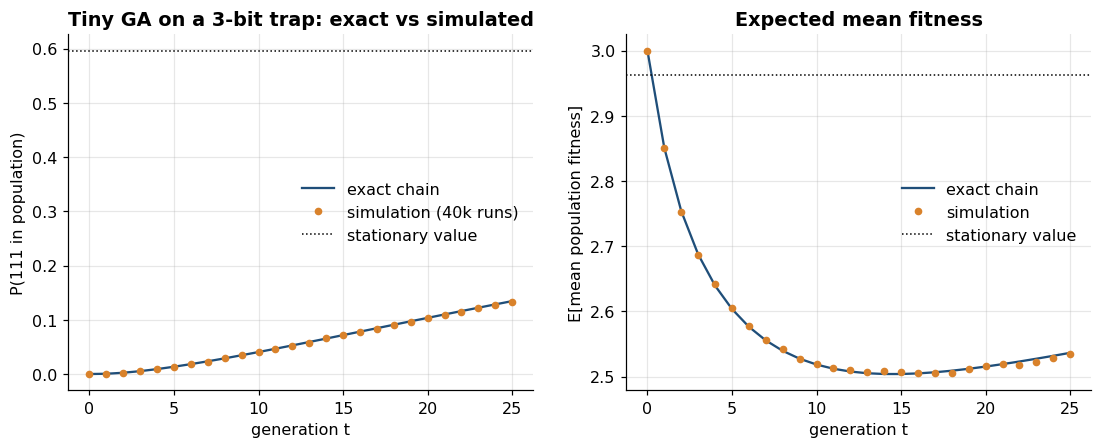

In [13]:
evals, evecs = np.linalg.eig(Q.T)
stat = np.real(evecs[:, np.argmin(np.abs(evals - 1))]); stat /= stat.sum()
check_close(np.abs(stat @ Q - stat).max(), 0.0, "stationary distribution: max |pi Q - pi|", atol=1e-12)
uniform_pops = S.max(1) == Npop
print(f"stationary: P(optimum present) = {stat @ contains_opt:.4f},  P(population uniform) = {stat @ uniform_pops:.4f},  "
      f"P(all copies of 000) = {stat[start]:.4f},  P(all copies of 111) = {stat[index[(0,) * (G2 - 1) + (Npop,)]]:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
tt = np.arange(gens + 1)
ax[0].plot(tt, exact_opt, "-", color=PALETTE["blue"], label="exact chain")
ax[0].plot(tt, sim_opt, "o", ms=4, color=PALETTE["orange"], label="simulation (40k runs)")
ax[0].axhline(stat @ contains_opt, color="k", ls=":", lw=1, label="stationary value")
ax[0].set(xlabel="generation t", ylabel="P(111 in population)", title="Tiny GA on a 3-bit trap: exact vs simulated")
ax[0].legend()
ax[1].plot(tt, exact_mf, "-", color=PALETTE["blue"], label="exact chain")
ax[1].plot(tt, sim_mf, "o", ms=4, color=PALETTE["orange"], label="simulation")
ax[1].axhline(stat @ meanfit_state, color="k", ls=":", lw=1, label="stationary value")
ax[1].set(xlabel="generation t", ylabel="E[mean population fitness]", title="Expected mean fitness")
ax[1].legend()
savefig("w4_nix_vose_chain.png"); plt.show()

With mutation the chain is irreducible and aperiodic, so it has a unique stationary distribution and every
population — including the optimal one — is visited infinitely often; without mutation the uniform populations
become absorbing and the GA converges to one of them (Nix & Vose 1992; Rudolph 1994 showed that the canonical GA
without elitism does *not* converge to the optimum in the sense of $P(\text{best} \in P_t) \to 1$, while the
elitist version does). The size of the state space, $\binom{2^\ell+N-1}{N}$, is why exact models are only a
microscope for tiny cases; as $N \to \infty$ the population follows the deterministic map $p_{t+1} = \mathcal{G}(p_t)$
(Vose 1999), the *infinite-population model*.

## Key takeaways

- The schema theorem is a correct one-step lower bound on *expected* schema counts; its disruption terms
  $p_c\,\delta/(L-1)$ and $o\,p_m$ quantify why short, low-order schemata propagate. It is not a convergence theorem.
- Deceptive traps show both sides of the building-block story: with tight linkage one-point crossover assembles
  blocks the (1+1) EA and uniform crossover cannot; with loose linkage the same GA fails.
- Rigorous runtime analysis gives exact, testable constants: $E[T] \sim e\,n\ln n$ (OneMax; exact chain fit gives
  $a = e$ and $b \approx -1.89$), and $E[T] = \frac{1}{2p^2}((1-p)^{-n+1}-(1-p)) \approx 0.859\,n^2$ (LeadingOnes).
- The Nix–Vose model turns a GA into an explicit Markov chain; exact and simulated trajectories agree, and the
  model explains convergence properties (irreducibility with mutation, absorption without).

## Exercises

1. ★ Extend the schema-theorem proof to uniform crossover: show that the disruption term becomes
   $p_c\,(1 - 2^{1-o(H)})$ in the worst case, and check it with the Monte Carlo code above.
2. ★ Prove the fitness-level upper bound $E[T] \le e\,n H_n$ for the (1+1) EA on OneMax, and compute the gap to the
   exact values in Section 4.1 for $n = 100$ and $n = 1000$.
3. ★★ Use the exact OneMax chain to find the static mutation rate $c/n$ minimising $E[T]$ for $n = 500$. Is $c = 1$
   optimal? (Compare with Witt 2013, who proved $1/n$ is asymptotically optimal on linear functions.)
4. ★★ Show that trap-$k$ is fully deceptive for every $k \ge 4$ (every competition of order $1 \le o \lt k$ is
   won *strictly* by the all-zeros schema), and that for $k = 3$ the order-2 competitions end in a tie. Then find
   experimentally the population size at which the tight-linkage GA of Section 3 solves all $m = 10$ blocks of
   trap-5 in at least 9 of 10 runs within 100 generations.
5. ★★ Remove mutation from the Nix–Vose model ($p_m = 0$). Identify the absorbing states, compute the absorption
   probabilities into the all-$111$ population from $\lbrace 000, 001, 010, 100\rbrace$, and verify by simulation.
6. ★★★ Build the infinite-population map $p \mapsto \mathcal{G}(p)$ for the 3-bit trap, iterate it from
   $p_0 = e_{000}$ and from the uniform distribution, locate its fixed points, and compare them with the stationary
   distribution of the finite-$N$ chain for $N = 2, 3, 4, 5$.